In [1]:
import numpy as np 
import healpy as hp
import pandas as pd
import matplotlib.pyplot as plt
import glob
import seaborn as sns
sns.set_style("darkgrid")
import matplotlib.pyplot as plt
import pandas as pd
from num2words import num2words as n2
import os
import rasterio
from scipy.interpolate import interp2d
from scipy.integrate import quad
from scipy.stats import multivariate_normal
from src2.country_choice import country_select
from src2.shapecheck import shapecheck as sc
from src2.get_nside import get_nside
from src2.FDrule import FDrule
sns.set(rc={"xtick.bottom": True, "ytick.left": True})
%matplotlib inline
# %matplotlib notebook

In [2]:
selval,path,path2=country_select()

Select 5k country: Brazil
9201 Tx in total


In [3]:
nside=get_nside()

Enter nside value:64


## read data from 5k country

In [4]:
usa_data=pd.read_csv(path)
usa_data=usa_data.dropna()

In [5]:
train_lon=usa_data['Longitude in degrees'].to_numpy()
train_lat=usa_data['Latitude in degrees'].to_numpy()
power=usa_data['EIRP'].to_numpy()
frequency=usa_data['Frequency(MHz)'].to_numpy()

## Remove zero power entries from database

In [6]:
valididx=np.nonzero(power)

In [7]:
train_lon=train_lon[valididx]
train_lat=train_lat[valididx]
power=power[valididx]
frequency=frequency[valididx]
train_pix=hp.ang2pix(nside,train_lon,train_lat,lonlat=True)

In [8]:
finval=selval-len(train_lon) #number of synth data required

In [9]:
power.min() #confirm non zero power data

5

## Visualize country lat lon bivariate distribution

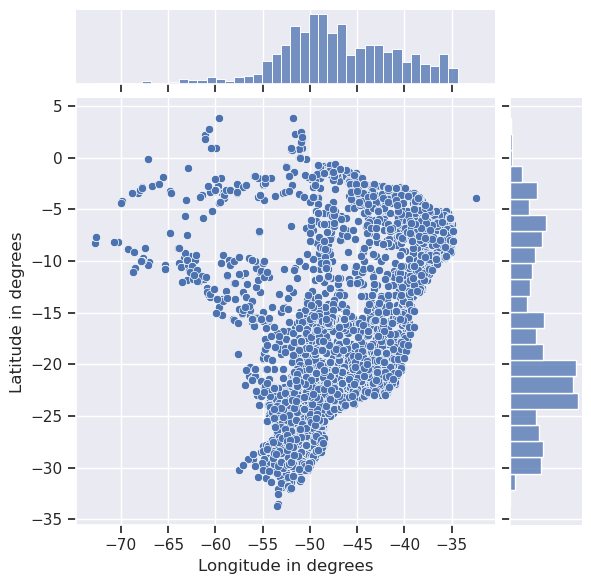

In [10]:
sns.jointplot(x='Longitude in degrees',y='Latitude in degrees',data=usa_data)
plt.show()

## Create 2D histogram and create a smooth PDF using 2D interpolation

In [11]:
data=np.column_stack((train_lon,train_lat))

## Select bin using Shimazaki method

In [12]:
minres=(hp.nside2resol(128,arcmin=True))/60

1
# -87.65825769084503 87 0.4635759897828862
# -87.65825769084503 80 0.46971874999999946


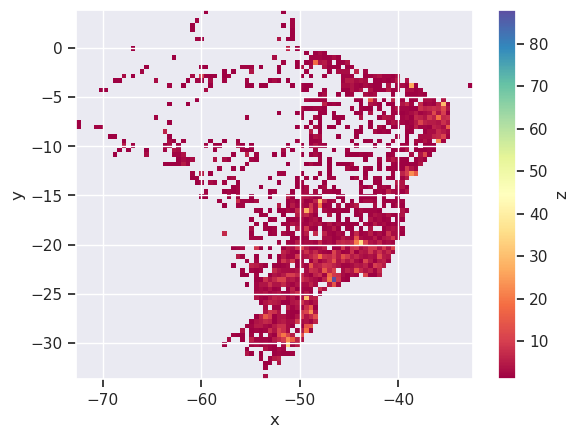

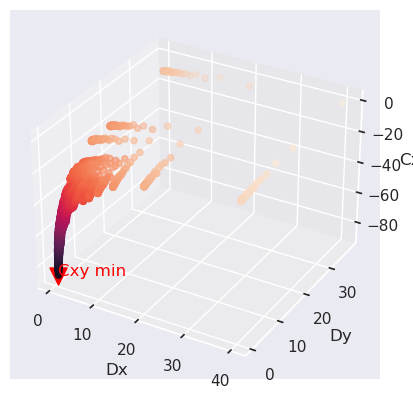

In [13]:
from numpy import arange, argmin, sum, mean, var, size, zeros, where, histogram

x = train_lon 
y = train_lat

x_max = max(x)
x_min = min(x)

y_max = max(y)
y_min = min(y)

Nx_MIN = 1  # Minimum number of bins in x (integer)
Nx_MAX = int((x_max-x_min)/minres)  # Maximum number of bins in x (integer)

Ny_MIN = 1  # Minimum number of bins in y (integer)
Ny_MAX = int((y_max-y_min)/minres)  # Maximum number of bins in y (integer)

Nx = arange(Nx_MIN, Nx_MAX)  # #of Bins
Ny = arange(Ny_MIN, Ny_MAX)  # #of Bins

Dx = (x_max - x_min) / Nx  # Bin size vector
Dy = (y_max - y_min) / Ny  # Bin size vector

Dxy = []
for i in Dx:  # Bin size vector
    a = []
    for j in Dy:  # Bin size vector
        a.append((i, j))
    Dxy.append(a)
Dxy = np.array(Dxy, dtype=[('x', float), ('y', float)])  # matrix of bin size vector

Cxy = zeros(np.shape(Dxy))

Cxy__Dxy_plot = []  # save data to plot in scatterplot x,y,z

# Computation of the cost function to x and y
for i in range(size(Nx)):
    for j in range(size(Ny)):
        ki = np.histogram2d(x, y, bins=(Nx[i], Ny[j]))
        ki = ki[0]  # The mean and the variance are simply computed from the event counts in all the bins of the 2-dimensional histogram.
        k = mean(ki)  # Mean of event count
        v = var(ki)  # Variance of event count
        Cxy[i, j] = (2 * k - v) / ((Dxy[i, j][0] * Dxy[i, j][1]) ** 2)  # The cost Function

        # (Cxy      , Dx          ,  Dy)
        Cxy__Dxy_plot.append((Cxy[i, j], Dxy[i, j][0], Dxy[i, j][1]))  # Save result of cost function to scatterplot

Cxy__Dxy_plot = np.array(Cxy__Dxy_plot, dtype=[('Cxy', float), ('Dx', float), ('Dy', float)])  # Save result of cost function to scatterplot

# Optimal Bin Size Selection

# combination of i and j that produces the minimum cost function
idx_min_Cxy = np.where(Cxy == np.min(Cxy))  # get the index of the min Cxy

Cxymin = Cxy[idx_min_Cxy[0][0], idx_min_Cxy[1][0]]  # value of the min Cxy

print(sum(Cxy == Cxymin))  # check if there is only one min value

optDxy = Dxy[idx_min_Cxy[0][0], idx_min_Cxy[1][0]]  # get the bins size pairs that produces the minimum cost function

optDx = optDxy[0]
optDy = optDxy[1]

idx_Nx = idx_min_Cxy[0][0]  # get the index in x that produces the minimum cost function
idx_Ny = idx_min_Cxy[1][0]  # get the index in y that produces the minimum cost function

print('#', Cxymin, Nx[idx_Nx], optDx)
print('#', Cxymin, Ny[idx_Ny], optDy)

# PLOTS

# plot histogram2d
fig = plt.figure()
H, xedges, yedges = np.histogram2d(x, y, bins=[Nx[idx_Nx], Ny[idx_Ny]])
Hmasked = np.ma.masked_where(H == 0, H)
plt.imshow(Hmasked.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], interpolation='nearest', origin='lower', aspect='auto', cmap=plt.cm.Spectral)
plt.ylabel("y")
plt.xlabel("x")
plt.colorbar().set_label('z')
plt.show()

# plot scatterplot3d to Dx,Dy and Cxy
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x = Cxy__Dxy_plot['Dx']
y = Cxy__Dxy_plot['Dy']
z = Cxy__Dxy_plot['Cxy']
ax.scatter(x, y, z, c=z, marker='o')

ax.set_xlabel('Dx')
ax.set_ylabel('Dy')
ax.set_zlabel('Cxy')
plt.draw()

ax.scatter([optDx], [optDy], [Cxymin], marker='v', s=150, c="red")
ax.text(optDx, optDy, Cxymin, "Cxy min", color='red')
plt.draw()
plt.show()


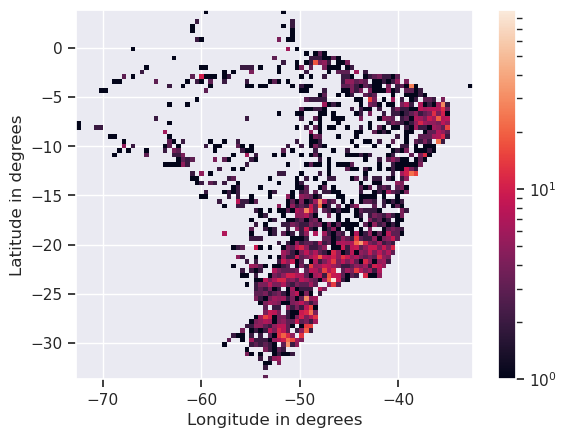

In [14]:
### from mpl_toolkits.axes_grid1 import make_axes_locatable
np.random.seed(42)


x, y = data.T
BIN_COUNT1 = Nx[idx_Nx]
BIN_COUNT2=Ny[idx_Ny]
hist, bins= np.histogramdd(data,bins=(BIN_COUNT1,BIN_COUNT2),density=True)
x_bins=bins[0]
y_bins=bins[1]
x_bin_midpoints = (x_bins[:-1] + x_bins[1:])/2
y_bin_midpoints = (y_bins[:-1] + y_bins[1:])/2

cdf = np.cumsum(hist.flatten())
cdf = cdf / cdf[-1]

# values = np.random.rand(finval)
# value_bins = np.searchsorted(cdf, values)
# x_idx, y_idx = np.unravel_index(value_bins,
#                                 (len(x_bin_midpoints),
#                                  len(y_bin_midpoints)))
# random_from_cdf = np.column_stack((x_bin_midpoints[x_idx],
#                                    y_bin_midpoints[y_idx]))
# new_x, new_y = random_from_cdf.T
plt.hist2d(x, y, bins=(BIN_COUNT1, BIN_COUNT2),norm='log')
plt.colorbar()
plt.xlabel('Longitude in degrees')
plt.ylabel('Latitude in degrees')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/2D_hist.pdf',dpi=600,bbox_inches='tight')
plt.show()

In [15]:
hist=hist.reshape(BIN_COUNT1,BIN_COUNT2) # reshape back for interpolation

## Create smooth PDF using RegularGridInterpolator

In [16]:
from scipy.interpolate import RegularGridInterpolator
x1=x_bins[:-1]
y1=y_bins[:-1]
V=hist

fn=RegularGridInterpolator((x1,y1),V,bounds_error=False,fill_value=0)


## Feed every possible pixel within country to interp func and get values

In [17]:
# France shapefile was downloaded from https://gadm.org/download_country.html and rasterized using QGIS
# Open the GeoTIFF file
file_path = path2
src = rasterio.open(file_path)

# Read the raster data as a numpy array
data = src.read(1)  

# Find pixels with non-zero values
non_zero_pixels = np.where(data != 0)

# Get the coordinates of non zero pixels
templat=[]
templon=[]
for y, x in zip(*non_zero_pixels):
    lonval, latval = src.xy(y, x)  # Get the longitude and latitude of the pixel
    templat.append(latval)
    templon.append(lonval)


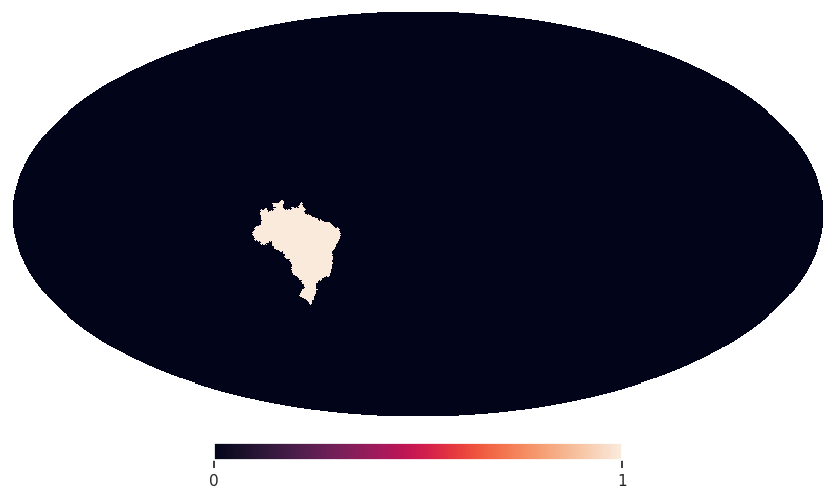

In [18]:
# country raster 
# Making a mask for generated data
temppix=hp.ang2pix(128,templon,templat,lonlat=True)
template=np.zeros(hp.nside2npix(128))
for pi in temppix:
    template[pi]+=1
template=np.where(template != 0, 1, 0)
hp.mollview(template,flip='geo',min=0,title='')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/Country_shp.pdf',dpi=600)

In [19]:
pop_pix=np.argwhere(template) # obtain non zero pix aka country pix
pop_pix=np.sort(pop_pix)
allon,allat=hp.pix2ang(128,pop_pix,lonlat=True)        
allon[allon>180]-=360
allon=allon.reshape(allon.shape[0])
allat=allat.reshape(allat.shape[0])

In [20]:
prob_vals=[] # obtain probabilty values for each pixel of the country (represented by allon and allat)
for i in range(len(allon)):
    a=allon[i]
    b=allat[i]
    prob_vals.append(fn([a,b]))
prob_vals=np.array(prob_vals)
prob_vals=prob_vals.reshape(prob_vals.shape[0]) 

In [21]:
prob_vals=prob_vals/np.sum(prob_vals) # normalize the PDF for generating synth data

In [22]:
prob_pix=hp.ang2pix(128,allon,allat,lonlat=True)
prob_healpix=np.zeros(hp.nside2npix(128))
for index,p in enumerate(prob_pix):
    prob_healpix[p]+=(prob_vals[index])

# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/new_Txpow',dpi=600)

## Resultant PDF heatmap of every pixel within the country

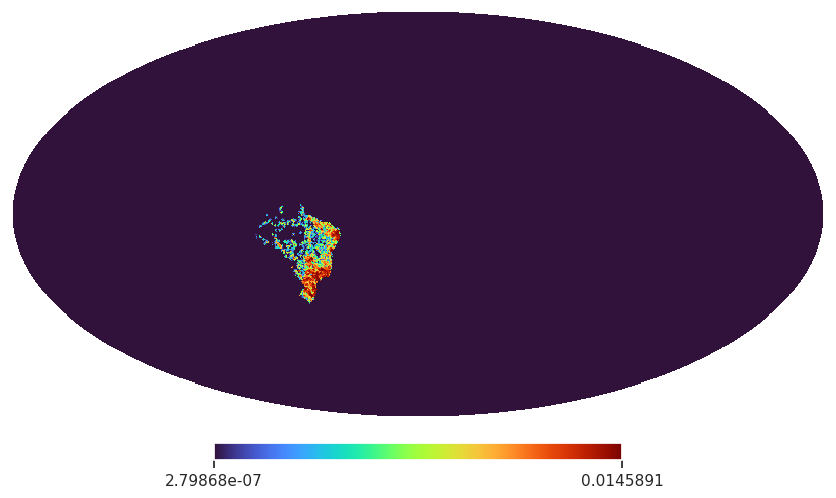

In [23]:
hp.mollview(prob_healpix,flip='geo',cmap='turbo',norm='hist',min=np.min(prob_healpix[np.nonzero(prob_healpix)]),title='')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/Prob_heatmap.pdf',dpi=600)#visualize PDF as a heatmap
plt.show()

In [24]:
pop_pix=pop_pix.reshape(pop_pix.shape[0]) 

## Synthetic Tx locations using the PDF

In [25]:
# Sample from all possible pixels in the country (pop_pix) using prob_vals as probabilty of each pixel
selpix=np.random.choice(pop_pix,size=finval,p=prob_vals) 

In [26]:
latestlon,latestlat=hp.pix2ang(128,selpix,lonlat=True) # Get lon lat of synth Tx
latestlon[latestlon>180]-=360


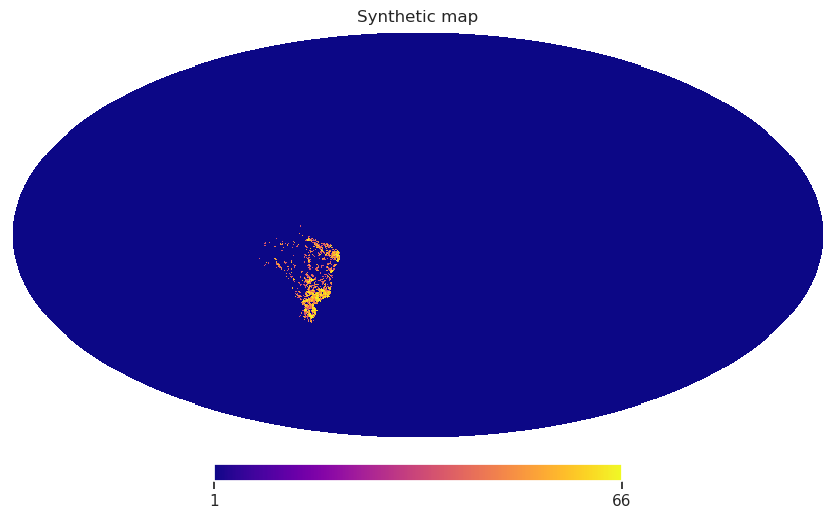

In [27]:
# make number of Tx per pixel map
Tx_new=np.zeros(hp.nside2npix(128))
for pi in selpix:
    Tx_new[pi]+=1
hp.mollview(Tx_new,flip='geo',cmap='plasma',norm='hist',title='Synthetic map',min=1)
plt.show()

In [28]:
np.sum(Tx_new)-finval # Ensure number of synth Tx is equal to required synth Tx

0.0

## CDF method for frequencies

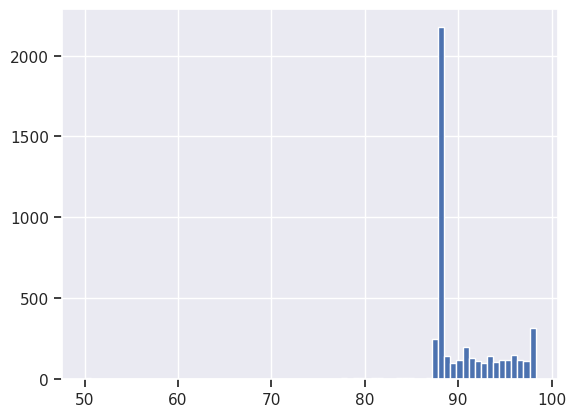

In [29]:
plt.hist(frequency,bins=FDrule(frequency))
plt.show()

In [30]:
data = frequency
# Creating histogram to estimate the CDF
hist1, bins1 = np.histogram(data, bins=FDrule(data), density=True)
cumulative1 = np.cumsum(hist1 * np.diff(bins1))  # Estimating cumulative distribution function (CDF)

In [31]:
new_freq = np.interp(np.random.uniform(0, 1, finval), (cumulative1), bins1[:-1])

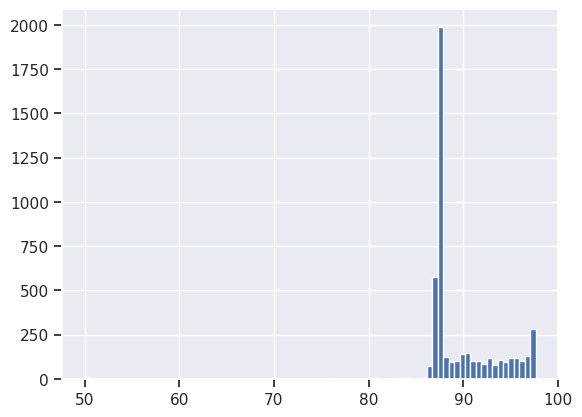

In [32]:
plt.hist(new_freq,bins=FDrule(new_freq))
plt.show()

## CDF method for Tx power

In [33]:
data2 = power
# Creating histogram to estimate the CDF
hist2, bins2 = np.histogram(data2, bins=FDrule(data2), density=True)
cumulative2 = np.cumsum(hist2 * np.diff(bins2))  # Estimating cumulative distribution function (CDF)

In [34]:
new_power= np.interp(np.random.uniform(0, 1, finval), (cumulative2), bins2[:-1])

In [35]:
# plt.hist(power,bins=FDrule(power),label='Original')
# plt.hist(new_power,bins=FDrule(new_power),label='Synth')
# plt.legend()
# plt.show()

## Create synthetic DB

In [36]:
daata={'Latitude in degrees':latestlat,'Longitude in degrees':latestlon,'Frequency(MHz)':new_freq,'EIRP':new_power}
synth_df=pd.DataFrame(daata)
# synth_df.to_csv('/home/pratush/Yogen_STARFIRE/Synth_DB/Brazil_synth.csv')